In [ ]:
import requests
import time
from bs4 import BeautifulSoup as bs
import lxml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
HEADERS = {"User-Agent": "Mozilla/5.0"}

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_American_exchange-traded_funds"

In [ ]:
resp = requests.get(url, headers=HEADERS)
time.sleep(1)

In [ ]:
soup = bs(resp.text, 'lxml')

In [ ]:
soup

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-theme-clientpref-thumb-standard" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>List of American exchange-traded funds - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main

In [ ]:
rows = soup.select('div > ul > li')

In [ ]:
rows

[<li class="mw-list-item" id="n-mainpage-description"><a accesskey="z" href="/wiki/Main_Page" title="Visit the main page [z]"><span>Main page</span></a></li>,
 <li class="mw-list-item" id="n-contents"><a href="/wiki/Wikipedia:Contents" title="Guides to browsing Wikipedia"><span>Contents</span></a></li>,
 <li class="mw-list-item" id="n-currentevents"><a href="/wiki/Portal:Current_events" title="Articles related to current events"><span>Current events</span></a></li>,
 <li class="mw-list-item" id="n-randompage"><a accesskey="x" href="/wiki/Special:Random" title="Visit a randomly selected article [x]"><span>Random article</span></a></li>,
 <li class="mw-list-item" id="n-aboutsite"><a href="/wiki/Wikipedia:About" title="Learn about Wikipedia and how it works"><span>About Wikipedia</span></a></li>,
 <li class="mw-list-item" id="n-contactpage"><a href="//en.wikipedia.org/wiki/Wikipedia:Contact_us" title="How to contact Wikipedia"><span>Contact us</span></a></li>,
 <li class="mw-list-item" id

In [ ]:
len(rows)

452

In [ ]:
type(rows[0])

bs4.element.Tag

In [ ]:
rows[0].text

'Main page'

In [ ]:
for row in rows:
	print(row.text)

Main page
Contents
Current events
Random article
About Wikipedia
Contact us
Help
Learn to edit
Community portal
Recent changes
Upload file
Special pages

Donate

Create account

Log in


Donate


Create account


Log in



(Top)





1
Stock ETFs




Toggle Stock ETFs subsection





1.1
Broad market ETFs








1.2
Index-tracking ETFs








1.3
Style ETFs






1.3.1
Large-cap ETFs








1.3.2
Mid-cap ETFs








1.3.3
Small-cap ETFs










1.4
International ETFs






1.4.1
Broad ex-US ETFs








1.4.2
Regional ex-US ETFs








1.4.3
Country ETFs






1.4.3.1
Developed ex-US markets








1.4.3.2
Emerging markets












1.5
Sector ETFs






1.5.1
US domestic sectors








1.5.2
Global sectors












2
Bond ETFs








3
Commodity ETFs




Toggle Commodity ETFs subsection





3.1
Broad basket








3.2
Agricultural ETFs








3.3
Energy commodity ETFs








3.4
Industrial commodity ETFs








3.5
Precious metals ETFs










4
Real estate ETFs


In [ ]:
bs_li_list = soup.body.find_all('li')

In [ ]:
bs_li_list[47:50]

[<li class="vector-toc-list-item vector-toc-level-1" id="toc-Asset_allocation">
 <a class="vector-toc-link" href="#Asset_allocation">
 <div class="vector-toc-text">
 <span class="vector-toc-numb">6</span>
 <span>Asset allocation</span>
 </div>
 </a>
 <ul class="vector-toc-list" id="toc-Asset_allocation-sublist">
 </ul>
 </li>,
 <li class="vector-toc-list-item vector-toc-level-1" id="toc-Active_ETFs">
 <a class="vector-toc-link" href="#Active_ETFs">
 <div class="vector-toc-text">
 <span class="vector-toc-numb">7</span>
 <span>Active ETFs</span>
 </div>
 </a>
 <ul class="vector-toc-list" id="toc-Active_ETFs-sublist">
 </ul>
 </li>,
 <li class="vector-toc-list-item vector-toc-level-1" id="toc-See_also">
 <a class="vector-toc-link" href="#See_also">
 <div class="vector-toc-text">
 <span class="vector-toc-numb">8</span>
 <span>See also</span>
 </div>
 </a>
 <ul class="vector-toc-list" id="toc-See_also-sublist">
 </ul>
 </li>]

In [ ]:
html = """
<html>
<body>
<div id="main">
<h1 class="title">뉴스제목</h1>
    <div class="articleSummary">
	    <a class="articleSubject" href="/news/001">기사 제목 1</a>
	    <span class="press"> 조선일보</span>
	    <span class="date">2024-01-01</span>
    </div>
    <div class="articleSummary">
	    <a class="articleSubject" href="/news/001">기사 제목 2</a>
	    <span class="press">한겨레</span>
	    <span class="date">2024-01-02</span>
    </div>
</div>
</body>
</html>
"""

In [ ]:
soup_2nd = bs(html, 'html.parser')

In [ ]:
soup_2nd


<html>
<body>
<div id="main">
<h1 class="title">뉴스제목</h1>
<div class="articleSummary">
<a class="articleSubject" href="/news/001">기사 제목 1</a>
<span class="press"> 조선일보</span>
<span class="date">2024-01-01</span>
</div>
<div class="articleSummary">
<a class="articleSubject" href="/news/001">기사 제목 2</a>
<span class="press">한겨레</span>
<span class="date">2024-01-02</span>
</div>
</div>
</body>
</html>

In [ ]:
soup_2nd.find('span')

<span class="press"> 조선일보</span>

In [ ]:
soup_2nd.select('.articleSummary')

[<div class="articleSummary">
 <a class="articleSubject" href="/news/001">기사 제목 1</a>
 <span class="press"> 조선일보</span>
 <span class="date">2024-01-01</span>
 </div>,
 <div class="articleSummary">
 <a class="articleSubject" href="/news/001">기사 제목 2</a>
 <span class="press">한겨레</span>
 <span class="date">2024-01-02</span>
 </div>]

In [ ]:
divs = soup_2nd.find('div', class_='articleSummary')

In [ ]:
divs

<div class="articleSummary">
<a class="articleSubject" href="/news/001">기사 제목 1</a>
<span class="press"> 조선일보</span>
<span class="date">2024-01-01</span>
</div>

In [ ]:
list(divs.children)

['\n',
 <a class="articleSubject" href="/news/001">기사 제목 1</a>,
 '\n',
 <span class="press"> 조선일보</span>,
 '\n',
 <span class="date">2024-01-01</span>,
 '\n']

In [ ]:
divs.parent

<div id="main">
<h1 class="title">뉴스제목</h1>
<div class="articleSummary">
<a class="articleSubject" href="/news/001">기사 제목 1</a>
<span class="press"> 조선일보</span>
<span class="date">2024-01-01</span>
</div>
<div class="articleSummary">
<a class="articleSubject" href="/news/001">기사 제목 2</a>
<span class="press">한겨레</span>
<span class="date">2024-01-02</span>
</div>
</div>

In [ ]:
divs.next_sibling

'\n'

In [ ]:
divs.next_sibling.next_sibling

<div class="articleSummary">
<a class="articleSubject" href="/news/001">기사 제목 2</a>
<span class="press">한겨레</span>
<span class="date">2024-01-02</span>
</div>

In [ ]:
bs_li_list[47]

<li class="vector-toc-list-item vector-toc-level-1" id="toc-Asset_allocation">
<a class="vector-toc-link" href="#Asset_allocation">
<div class="vector-toc-text">
<span class="vector-toc-numb">6</span>
<span>Asset allocation</span>
</div>
</a>
<ul class="vector-toc-list" id="toc-Asset_allocation-sublist">
</ul>
</li>

In [ ]:
'NYSE' in bs_li_list[80].text

True

In [ ]:
for i in bs_li_list:
	print(i.text)

Main page
Contents
Current events
Random article
About Wikipedia
Contact us
Help
Learn to edit
Community portal
Recent changes
Upload file
Special pages

Donate

Create account

Log in


Donate


Create account


Log in



(Top)





1
Stock ETFs




Toggle Stock ETFs subsection





1.1
Broad market ETFs








1.2
Index-tracking ETFs








1.3
Style ETFs






1.3.1
Large-cap ETFs








1.3.2
Mid-cap ETFs








1.3.3
Small-cap ETFs










1.4
International ETFs






1.4.1
Broad ex-US ETFs








1.4.2
Regional ex-US ETFs








1.4.3
Country ETFs






1.4.3.1
Developed ex-US markets








1.4.3.2
Emerging markets












1.5
Sector ETFs






1.5.1
US domestic sectors








1.5.2
Global sectors












1.1
Broad market ETFs








1.2
Index-tracking ETFs








1.3
Style ETFs






1.3.1
Large-cap ETFs








1.3.2
Mid-cap ETFs








1.3.3
Small-cap ETFs










1.3.1
Large-cap ETFs








1.3.2
Mid-cap ETFs








1.3.3
Small-cap ETFs








1.4
I

In [ ]:
def extract_market_ticker(text):
    begin_index = text.find('(')
    end_index = text.find(')')
    if text[begin_index+1:begin_index+4] == 'NERD':
        market_ticker = text[begin_index+6:end_index]
    else:
        market_ticker = text[begin_index+1:end_index]
    market = market_ticker[:9]
    ticker = market_ticker[10:]
    return market, ticker

def extract_etf_name(text):
    begin_index = text.find('(')
    return text[:begin_index].strip()

etf_data_list = []
for i in range(len(bs_li_list)):
    etf_info = bs_li_list[i].text
    if 'NYSE' in etf_info:
        etf_name = extract_etf_name(etf_info)
        market_ticker = extract_market_ticker(etf_info)
        market = market_ticker[0]
        ticker = market_ticker[1]
        etf_data_list.append([ticker, market, etf_name])
etf_df = pd.DataFrame(etf_data_list)
etf_df_t = etf_df.T
etf_df_t.columns = etf_df_t.iloc[0]
etf_df_t = etf_df_t[1:]
etf_df_t

,ITOT,IWV,SCHB,FNDB,VT,VTI,VXUS,VTHR,DIA,RSP,...,GAL,INKM,RLY,SRLN,ULST,CEW,CYB,ELD,EMCB,USDU
1,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,...,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca
2,iShares Core S&P Total US Stock Mkt,iShares Russell 3000 Index,Schwab US Broad Market ETF,Schwab Fundamental U.S. Broad Market Index ETF,Vanguard Total World Stock,Vanguard Total Stock Market,Vanguard Total International Stock,Vanguard Russell 3000,"DIAMONDS Trust, Series 1",Guggenheim S&P 500 Equal Weight,...,SPDR SSgA Global Allocation,SPDR SSgA Income Allocation,SPDR SSgA Multi-Asset Real Return,SPDR Blackstone/GSO Senior Loan ETF,SPDR SSgA Ultra Short Term Bond ETF,WisdomTree Dreyfus Emerging Currency,WisdomTree Dreyfus Chinese Yuan,WisdomTree Emerging Markets Local Debts Fund,WisdomTree Emerging Markets Corporate Bond Fund,WisdomTree Bloomberg U.S. Dollar Bullish Fund


In [ ]:
etf_data_list

[['\xa0ITOT', 'NYSE\xa0Arca', 'iShares Core S&P Total US Stock Mkt'],
 ['\xa0IWV', 'NYSE\xa0Arca', 'iShares Russell 3000 Index'],
 ['\xa0SCHB', 'NYSE\xa0Arca', 'Schwab US Broad Market ETF'],
 ['\xa0FNDB',
  'NYSE\xa0Arca',
  'Schwab Fundamental U.S. Broad Market Index ETF'],
 ['\xa0VT', 'NYSE\xa0Arca', 'Vanguard Total World Stock'],
 ['\xa0VTI', 'NYSE\xa0Arca', 'Vanguard Total Stock Market'],
 ['\xa0VXUS', 'NYSE\xa0Arca', 'Vanguard Total International Stock'],
 ['\xa0VTHR', 'NYSE\xa0Arca', 'Vanguard Russell 3000'],
 ['DIA', 'NYSE Arca', 'DIAMONDS Trust, Series 1'],
 ['RSP', 'NYSE Arca', 'Guggenheim S&P 500 Equal Weight'],
 ['IOO', 'NYSE Arca', 'iShares S&P Global 100 Index'],
 ['IVV', 'NYSE Arca', 'iShares S&P 500 Index'],
 ['SPY', 'NYSE Arca', 'SPDR S&P 500'],
 ['VOO', 'NYSE Arca', 'Vanguard S&P 500'],
 ['IWM', 'NYSE Arca', 'iShares Russell 2000 Index'],
 ['OEF', 'NYSE Arca', 'iShares S&P 100 Index'],
 ['CVY', 'NYSE Arca', 'Guggenheim Multi-Asset Income'],
 ['RPG', 'NYSE Arca', 'Gugge

In [ ]:
data_dict = {}

In [ ]:
for i in etf_data_list:
    data_dict[i[0]] = i[1:]

In [ ]:
data_dict

{'\xa0ITOT': ['NYSE\xa0Arca', 'iShares Core S&P Total US Stock Mkt'],
 '\xa0IWV': ['NYSE\xa0Arca', 'iShares Russell 3000 Index'],
 '\xa0SCHB': ['NYSE\xa0Arca', 'Schwab US Broad Market ETF'],
 '\xa0FNDB': ['NYSE\xa0Arca',
  'Schwab Fundamental U.S. Broad Market Index ETF'],
 '\xa0VT': ['NYSE\xa0Arca', 'Vanguard Total World Stock'],
 '\xa0VTI': ['NYSE\xa0Arca', 'Vanguard Total Stock Market'],
 '\xa0VXUS': ['NYSE\xa0Arca', 'Vanguard Total International Stock'],
 '\xa0VTHR': ['NYSE\xa0Arca', 'Vanguard Russell 3000'],
 'DIA': ['NYSE Arca', 'DIAMONDS Trust, Series 1'],
 'RSP': ['NYSE Arca', 'Guggenheim S&P 500 Equal Weight'],
 'IOO': ['NYSE Arca', 'iShares S&P Global 100 Index'],
 'IVV': ['NYSE Arca', 'iShares S&P 500 Index'],
 'SPY': ['NYSE Arca', 'SPDR S&P 500'],
 'VOO': ['NYSE Arca', 'Vanguard S&P 500'],
 'IWM': ['NYSE Arca', 'iShares Russell 2000 Index'],
 'OEF': ['NYSE Arca', 'iShares S&P 100 Index'],
 'CVY': ['NYSE Arca', 'Guggenheim Multi-Asset Income'],
 'RPG': ['NYSE Arca', 'Guggenh

In [ ]:
df = pd.DataFrame(data_dict)

In [ ]:
df

,ITOT,IWV,SCHB,FNDB,VT,VTI,VXUS,VTHR,DIA,RSP,...,GAL,INKM,RLY,SRLN,ULST,CEW,CYB,ELD,EMCB,USDU
0,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,...,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca,NYSE Arca
1,iShares Core S&P Total US Stock Mkt,iShares Russell 3000 Index,Schwab US Broad Market ETF,Schwab Fundamental U.S. Broad Market Index ETF,Vanguard Total World Stock,Vanguard Total Stock Market,Vanguard Total International Stock,Vanguard Russell 3000,"DIAMONDS Trust, Series 1",Guggenheim S&P 500 Equal Weight,...,SPDR SSgA Global Allocation,SPDR SSgA Income Allocation,SPDR SSgA Multi-Asset Real Return,SPDR Blackstone/GSO Senior Loan ETF,SPDR SSgA Ultra Short Term Bond ETF,WisdomTree Dreyfus Emerging Currency,WisdomTree Dreyfus Chinese Yuan,WisdomTree Emerging Markets Local Debts Fund,WisdomTree Emerging Markets Corporate Bond Fund,WisdomTree Bloomberg U.S. Dollar Bullish Fund


In [ ]:
data_dict = {k.replace(u'\xa0', u''): v for k, v in data_dict.items()}

In [ ]:
data_dict

{'ITOT': ['NYSE\xa0Arca', 'iShares Core S&P Total US Stock Mkt'],
 'IWV': ['NYSE\xa0Arca', 'iShares Russell 3000 Index'],
 'SCHB': ['NYSE\xa0Arca', 'Schwab US Broad Market ETF'],
 'FNDB': ['NYSE\xa0Arca', 'Schwab Fundamental U.S. Broad Market Index ETF'],
 'VT': ['NYSE\xa0Arca', 'Vanguard Total World Stock'],
 'VTI': ['NYSE\xa0Arca', 'Vanguard Total Stock Market'],
 'VXUS': ['NYSE Arca', 'Vanguard Total International Stock'],
 'VTHR': ['NYSE\xa0Arca', 'Vanguard Russell 3000'],
 'DIA': ['NYSE Arca', 'DIAMONDS Trust, Series 1'],
 'RSP': ['NYSE Arca', 'Guggenheim S&P 500 Equal Weight'],
 'IOO': ['NYSE Arca', 'iShares S&P Global 100 Index'],
 'IVV': ['NYSE Arca', 'iShares S&P 500 Index'],
 'SPY': ['NYSE Arca', 'SPDR S&P 500'],
 'VOO': ['NYSE Arca', 'Vanguard S&P 500'],
 'IWM': ['NYSE Arca', 'iShares Russell 2000 Index'],
 'OEF': ['NYSE Arca', 'iShares S&P 100 Index'],
 'CVY': ['NYSE Arca', 'Guggenheim Multi-Asset Income'],
 'RPG': ['NYSE Arca', 'Guggenheim S&P 500 Pure Growth ETF'],
 'RPV'

# 동적 크롤링
라이브러리 종류

- selenuim
- playwright

기능
- 페이지 열기
- 버튼 클릭
- 텍스트 입력
- 스크롤
- 데이터 추출

By.Class_Name, 'no_today'

By.XPATH

By.CSS_SELECTOR

//*[@id="rate_info_krx"]/div/p[1]

DOM(Document Object Model), iframe

문서객체모델
문서 객체 모델(DOM)은 HTML 문서 구조를 객체로 표현한 것이에요. 영어로는 Document Object Model이라고 하지만 약어인 DOM으로 주로 표기돼요. 그래서 한국어로도 '돔'이라고 불리고요.
즉, DOM은 HTML로 구성된 웹 페이지와 스크립트 및 프로그래밍 언어를 연결시켜주는 역할을 해요.

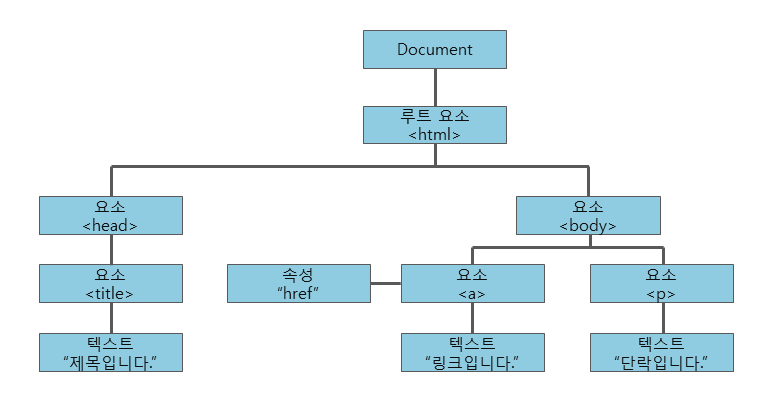

iframe
iframe이란 inline frame의 약자입니다.

iframe 요소를 이용하면 해당 웹 페이지 안에 어떠한 제한 없이 또 다른 하나의 웹 페이지를 삽입할 수 있습니다.

# 1. iframe으로 전환

```python
drive.switch_to.frame('_ifr_nxt0') # iframe의 id 또는 name

drive.switch_to.default_content()
```

In [ ]:
# 삼성전자 주가 크롤링
from selenium import webdriver
import os
os.environ['WDM_LOCAL']='1'

from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
import time

options = Options()
options.add_argument("--headless=new")

def element_process(element):
    temp = ''.join(element.text.split()).replace(',', '')
    print(temp)

try:
    driver = webdriver.Chrome(options=options, service=Service(ChromeDriverManager().install()))
    code_number = '005930'
    driver.get(f"https://finance.naver.com/item/main.naver?code={code_number}")

    # price_element = driver.find_element(By.CSS_SELECTOR, '#rate_info_krx > div > p.no_today') # krx => 장중 nxt => 장마감
    price_element = price_element = driver.find_element(By.CSS_SELECTOR, '#rate_info_nxt > div > p.no_today > em > span.blind')
    element_process(price_element)

    # last_string = driver.find_element(By.CLASS_NAME, 'sptxt')
    # last_price = driver.find_element(By.CSS_SELECTOR, 'p.no_exday')
    # print(last_price)
    time.sleep(2)
except Exception as e:
    print(e)
finally:
    driver.quit()

'''
price_xpath = driver.find_element(By.XPATH, '//*[@id="rate_info_krx"]/div/p[1]')
element_process(price_xpath)

price_css = driver.find_element(By.CSS_SELECTOR, '#rate_info_krx > div > p.no_today')
element_process(price_css)
'''